# preliminary fit of ALPT bias parameters

In [1]:
import os
import numpy as np
import numba as nb
from numba import njit, prange, int64

In [2]:
import matplotlib.pyplot as plt

In [3]:
from geneticalgorithm import geneticalgorithm as ga

In [4]:
np.random.seed(123456)

## read reference Quijote+HOD simulation

In [5]:
from hodalpt.sims.quijote import HODgalaxies
theta_hod = {}
theta_hod['logMmin'] = 13.0
theta_hod['sigma_logM'] = 0.4
theta_hod['logM0'] = 13.67
theta_hod['logM1'] = 13.68
theta_hod['alpha'] = 0.79
theta_hod['Abias'] = 0.0
theta_hod['eta_conc'] = 1.11
theta_hod['eta_cen'] = 0.31
theta_hod['eta_sat'] = 0.85

hod = HODgalaxies(theta_hod, '/Users/chang/data/simbig/quijote/fiducial_HR/0')

/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/phase_space_models/analytic_models/satellites/nfw/biased_nfw_phase_space.py:225: UserWarning: You have selected 18 bins to digitize host halo concentration 
and 96 bins to digitize the galaxy bias parameter.
To populate mocks, the BiasedNFWPhaseSpace class builds a lookup table with shape (18, 96, 101),
one entry for every numerical solution to the Jeans equation.
Using this fine of a binning requires a long pre-computation of 174528 integrals
.Make sure you actually need to use so many bins
  warn(lookup_table_performance_warning.format(*args))
/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/factories/hod_model_factory.py:890: UserWarning: The composite model received multiple component models 
with a new_haloprop_func_dict that use the conc_NFWmodel key. 
Ignoring the one that appears in the profile component for satellite

In [6]:
from nbodykit.lab import ArrayCatalog, FFTPower

In [7]:
data = {'Position': np.array(hod['Position'])}
cat = ArrayCatalog(data, BoxSize=1000., Nmesh=256)
galmesh = cat.to_mesh(Nmesh=256, BoxSize=1000., resampler='NEAREST', compensated=False, interlaced=True).to_real_field(normalize=False).value  # shape (nmesh, nmesh, nmesh)

In [8]:
@njit(cache=True)
def k_squared(lbox,ngrid,ii,jj,kk):
    
      kfac = 2.0*np.pi/lbox

      if ii <= ngrid/2:
        kx = kfac*ii
      else:
        kx = -kfac*(ngrid-ii)
      
      if jj <= ngrid/2:
        ky = kfac*jj
      else:
        ky = -kfac*(ngrid-jj)
      
      #if kk <= nc/2:
      kz = kfac*kk
      #else:
      #  kz = -kfac*np.float64(nc-k)
      
      k2 = kx**2+ky**2+kz**2

      return k2

@njit(cache=True)
def k_squared_nohermite(lbox,ngrid,ii,jj,kk):

      kfac = 2.0*np.pi/lbox

      if ii <= ngrid/2:
        kx = kfac*ii
      else:
        kx = -kfac*(ngrid-ii)

      if jj <= ngrid/2:
        ky = kfac*jj
      else:
        ky = -kfac*(ngrid-jj)

      if kk <= ngrid/2:
          kz = kfac*kk
      else:
          kz = -kfac*(ngrid-kk)                                                                                                           

      k2 = kx**2+ky**2+kz**2

      return k2

@njit(parallel=False, cache=True)
def get_power(fsignal, Nbin, kmax, dk, kmode, power, nmode, ngrid=256, lbox=1000.):
    
    for i in prange(ngrid):
        for j in prange(ngrid):
            for k in prange(ngrid):
                ktot = np.sqrt(k_squared_nohermite(lbox,ngrid,i,j,k))
                if ktot <= kmax:
                    nbin = int(ktot/dk-0.5)
                    akl = fsignal.real[i,j,k]
                    bkl = fsignal.imag[i,j,k]
                    kmode[nbin]+=ktot
                    power[nbin]+=(akl*akl+bkl*bkl)
                    nmode[nbin]+=1

    for m in prange(Nbin):
        if(nmode[m]>0):
            kmode[m]/=nmode[m]
            power[m]/=nmode[m]

    power = power / (ngrid/2)**3

    return kmode, power, nmode


def measure_spectrum(signal, ngrid=256, lbox=1000.):

    nbin = round(ngrid/2)
    
    fsignal = np.fft.fftn(signal) 

    kmax = np.pi * ngrid / lbox 
    dk = kmax/nbin  # Bin width

    nmode = np.zeros((nbin))
    kmode = np.zeros((nbin))
    power = np.zeros((nbin))

    kmode, power, nmode = get_power(fsignal, nbin, kmax, dk, kmode, power, nmode)
    
    return kmode[1:], power[1:]

@njit(fastmath=True, cache=True)
def negative_binomial(n, p):
    if n>0:
        if p > 0. and p < 1.:
            gfunc = np.random.gamma(n, (1. - p) / p)
            Y = np.random.poisson(gfunc)

    else:
        Y = 0

    return Y

## define bias model

In [25]:
@njit(parallel=True, cache=True, fastmath=True)
def biasmodel(ngrid, lbox, delta, tweb, twebdelta, nmean, alpha, beta, rhoeps, eps, twebenv, twebdeltaenv):

    ncounts = np.zeros((ngrid,ngrid,ngrid))

    # FIRST LOOP: deterministic bias
    # Parallelize the outer loop
    for ii in prange(ngrid):
        for jj in range(ngrid):
            for kk in range(ngrid):
                 # Sample number counts (dth=-1 hardcoded)
                if tweb[ii,jj,kk]==twebenv and twebdelta[ii,jj,kk]==twebdeltaenv and delta[ii,jj,kk] >= -1:
                    ncounts[ii,jj,kk] = (1.+delta[ii,jj,kk])**alpha * np.exp(-((1 + delta[ii,jj,kk])/rhoeps)**eps)# * np.exp(-((1 + delta[ii,jj,kk])/rhoepsprime)**epsprime)
                else:
                    ncounts[ii,jj,kk] = 0. #

    nc = 0.
    for ii in range(ngrid):
        for jj in range(ngrid):
            for kk in range(ngrid):
                # Sample number counts
                if tweb[ii,jj,kk]==twebenv and twebdelta[ii,jj,kk]==twebdeltaenv:
                    nc+= ncounts[ii,jj,kk]
    
    denstot = nc / lbox**3

    normal = nmean / denstot
    
    for ii in prange(ngrid):
        for jj in range(ngrid):
            for kk in range(ngrid):

                ncounts[ii,jj,kk] = nmean / denstot *  ncounts[ii,jj,kk]
                pnegbin = 1 - ncounts[ii,jj,kk]/(ncounts[ii,jj,kk] + beta)

                ncounts[ii,jj,kk] = negative_binomial(beta, pnegbin)

    return ncounts, normal

In [21]:
def chisquare(xx, plot_pk=False, verbose=False, ngrid=256, lbox=1000., twebenv=None, twebdeltaenv=None):
    # Define the parameters to fit
    alpha = xx[0]
    beta = xx[1]
    rhoeps = xx[2]
    eps = xx[3]
    
    ncounts_new, normalization = biasmodel(ngrid, lbox, delta, tweb, dweb, meandens, alpha, beta, rhoeps, eps, twebenv, twebdeltaenv)

    if verbose: 
        print('Maximum number of galaxies in cells: ', np.amax(ncounts_new))
        print('Total number of galaxies: ', np.sum(ncounts_new))

    ncounts_new_mask = np.zeros((ngrid,ngrid,ngrid))
    ncounts_new_mask[np.logical_and(tweb==twebenv,twebdelta==twebdeltaenv)] = ncounts_new[np.logical_and(tweb==twebenv,twebdelta==twebdeltaenv)]

    kk, pk = measure_spectrum(ncounts_new_mask)

    chisq = np.sum((pk[np.where(kk<kkth)]/pkgal[np.where(kk<kkth)] - 1.)**2)/len(pk[np.where(kk<kkth)])

    #chisq = weight_l0*chisq_l0 + weight_l2*chisq_l2

    if verbose == True:
        print('PARS: ', xx)
        print('Monopole ratios (%): ', (pk[np.where(kk<kkth)]/pkgal[np.where(kk<kkth)] - 1.)*100.)
        #print('Quadrupole ratios (%): ', (pk_l2[np.where(kk<kkth_l2)]/pkref_l2[np.where(kk<kkth_l2)] - 1.)*100.)
        print('----------------------------------------------')


    if plot_pk == True:
        plt.plot(kk, pkgal/pkgal, color='red', label='Ref')
        plt.plot(kk, pk/pkgal, color='green', linestyle='dashed', label='Mock')
        plt.fill_between(kk, 0.99*np.ones(len(kk)), 1.01*np.ones(len(kk)), color='gray', alpha=0.7)
        plt.fill_between(kk, 0.98*np.ones(len(kk)), 1.02*np.ones(len(kk)), color='gray', alpha=0.5)
        plt.fill_between(kk, 0.95*np.ones(len(kk)), 1.05*np.ones(len(kk)), color='gray', alpha=0.3)
        plt.fill_between(kk, 0.9*np.ones(len(kk)), 1.1*np.ones(len(kk)), color='gray', alpha=0.2)
        plt.xlabel('k')
        plt.ylabel('P(k) ratios')
        plt.xscale('log')
        #plt.yscale('log')
        #plt.ylim([0.85, 1.15])
        plt.legend()
        #plt.savefig('pk_ratios_ngp_rspace_z%s.pdf' %zstring, bbox_inches='tight')
        plt.show()

    return chisq

In [13]:
Ngrid = 256
Lbox = 1000.
    
dm_dir = '/Users/chang/data/simbig/quijote/fiducial_HR/0/alpt/'

delta = np.fromfile(os.path.join(dm_dir, 'super_deltaBox.dat'), dtype=np.float32)  # In real space
delta = np.reshape(delta, (Ngrid,Ngrid,Ngrid))

tweb = np.fromfile(os.path.join(dm_dir, 'Tweb_.dat'), dtype=np.float32)  # In real space
tweb = np.reshape(tweb, (Ngrid,Ngrid,Ngrid))

dweb = np.fromfile(os.path.join(dm_dir, 'TwebDelta_.dat'), dtype=np.float32)  # In real space 
dweb = np.reshape(dweb, (Ngrid,Ngrid,Ngrid))

print(np.amin(delta), np.amax(delta))

-1.0 186.50102


In [14]:
tweb = tweb.astype(int) - 1 
dweb = dweb.astype(int) - 1

5.2351086e-05
Fitting ...
 The best solution found:                                                                           
 [ 1.53998828 78.39327382 10.55641997  0.56062951]

 Objective function:
 0.017295267039835603


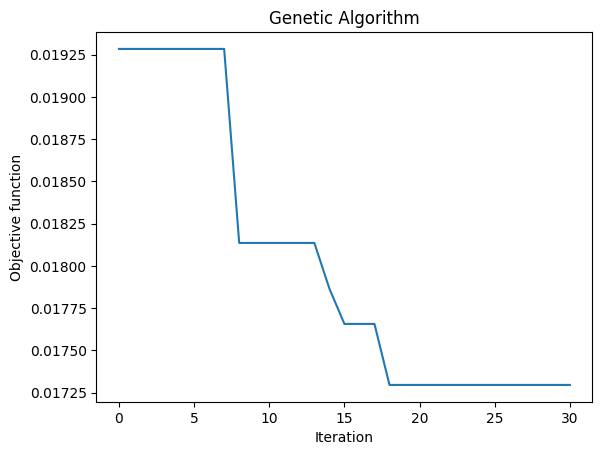

In [26]:
itweb = 0 
idweb = 0

kkth = 0.5

alpha_bounds = (0.01, 3.)
beta_bounds = (0.1, 100.)
dth_bounds = (-1, 0.5)
rhoeps_bounds = (0.3, 20.)
eps_bounds = (0.1, 3.)
bounds = np.array([alpha_bounds, beta_bounds, rhoeps_bounds, eps_bounds])

meandens = np.sum(galmesh[np.logical_and(tweb==itweb, dweb==idweb)])/Lbox**3
print(meandens)

ncounts_mask = np.zeros((Ngrid,Ngrid,Ngrid))
ncounts_mask[np.logical_and(tweb==itweb, dweb==idweb)] = galmesh[np.logical_and(tweb==itweb, dweb==idweb)]

kkgal, pkgal = measure_spectrum(ncounts_mask)

def _chisquare(xx): 
    # Define the parameters to fit
    alpha = xx[0]
    beta = xx[1]
    rhoeps = xx[2]
    eps = xx[3]
    
    ncounts_new, normalization = biasmodel(Ngrid, Lbox, delta, tweb, dweb, meandens, alpha, beta, rhoeps, eps, itweb, idweb)

    ncounts_new_mask = np.zeros((Ngrid, Ngrid, Ngrid))
    ncounts_new_mask[np.logical_and(tweb==itweb, dweb==idweb)] = ncounts_new[np.logical_and(tweb==itweb, dweb==idweb)]

    kk, pk = measure_spectrum(ncounts_new_mask)

    return np.sum((pk[np.where(kk < kkth)]/pkgal[np.where(kk < kkth)] - 1.)**2)/len(pk[np.where(kk<kkth)]) 

print('Fitting ...')
algorithm_param = {'max_num_iteration': 100,
           'population_size':100,
           'mutation_probability':0.1,
           'elit_ratio': 0.01,
           'crossover_probability': 0.5,
           'parents_portion': 0.3,
           'crossover_type':'uniform',
           'max_iteration_without_improv':10}
    
model=ga(function=_chisquare, 
         dimension=4,
         variable_type='real', 
         variable_boundaries=bounds, 
         algorithm_parameters=algorithm_param)
model.run()
convergence = model.report
solution = model.output_dict
    
x0new = solution['variable']

In [27]:
x0new

array([ 1.53998828, 78.39327382, 10.55641997,  0.56062951])

In [28]:
ncounts_new, normalization = biasmodel(Ngrid, Lbox, delta, tweb, dweb, meandens, x0new[0], x0new[1], x0new[2], x0new[3], itweb, idweb)
ncounts_new_mask = np.zeros((Ngrid, Ngrid, Ngrid))
ncounts_new_mask[np.logical_and(tweb==itweb, dweb==idweb)] = ncounts_new[np.logical_and(tweb==itweb, dweb==idweb)]

kk, pk = measure_spectrum(ncounts_new_mask)

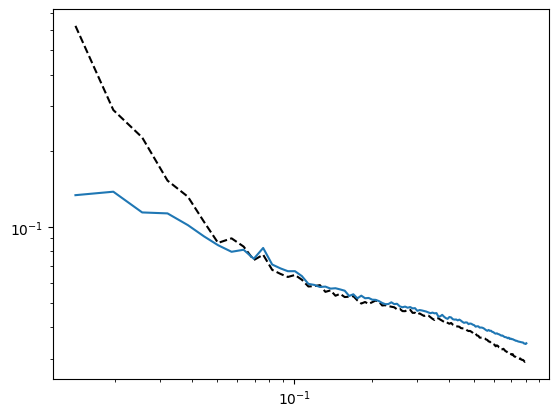

In [29]:
plt.loglog(kkgal, pkgal, c='k', ls='--')
plt.loglog(kk, pk)